# Physical Climate Risk Assessment
### Sample project using dummy data | Netherlands asset portfolio | Horizon 2050

This notebook walks through a geospatial physical climate risk analysis from scratch.
It uses entirely made-up data so you can run it immediately and see how the pipeline works
before connecting real client assets or hazard rasters.

The workflow covers:
1. Building a GeoDataFrame of asset locations
2. Projecting and running spatial operations with GeoPandas
3. Overlaying hazard zones and computing exposure
4. Classifying risk tiers (Critical / High / Medium / Low)
5. Producing an interactive map, a risk matrix chart, and a summary table

Everything lives in an `output/` folder that gets created automatically.

## 1. Setup

Install the packages you need. This is safe to re-run and skips anything already installed.

In [1]:
import subprocess, sys

packages = ["geopandas", "pandas", "numpy", "matplotlib",
            "contextily", "rasterstats", "folium", "shapely"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages ready.")

All packages ready.


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import contextily as ctx
import folium
from shapely.geometry import Point, Polygon, box
from shapely.ops import unary_union
import warnings
import os

warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)
np.random.seed(42)

print(f"GeoPandas version: {gpd.__version__}")
print("Imports OK. Output folder is ready.")

GeoPandas version: 1.1.3
Imports OK. Output folder is ready.


## 2. Create the asset GeoDataFrame

We start by building a table of asset locations and converting it straight into a
GeoDataFrame. This is the core object for everything that follows.

Each row is one property in a fictional real estate portfolio spread across the Netherlands.
The `geometry` column holds a Shapely Point for each asset, referenced in WGS84 (EPSG:4326).

In [3]:
# Dummy portfolio: 15 assets with names, sectors, coordinates and book values
data = {
    "asset_id":   [f"NL{i:03d}" for i in range(1, 16)],
    "asset_name": [
        "Rotterdam Warehouse A", "Amsterdam Office Tower", "Utrecht Data Centre",
        "Dordrecht Logistics Hub", "Middelburg Industrial Park", "Groningen Farm Complex",
        "Nijmegen Factory", "Maastricht Office Block", "Almere Distribution Centre",
        "The Hague HQ", "Eindhoven Tech Campus", "Haarlem Retail Park",
        "Tilburg Manufacturing", "Arnhem Storage Facility", "Leeuwarden Agri Site"
    ],
    "sector": [
        "logistics", "office", "tech", "logistics", "industrial",
        "agriculture", "manufacturing", "office", "logistics",
        "office", "tech", "retail", "manufacturing", "logistics", "agriculture"
    ],
    "lat": [51.921, 52.374, 52.090, 51.814, 51.500,
            53.219, 51.843, 50.851, 52.370, 52.070,
            51.440, 52.388, 51.555, 51.984, 53.201],
    "lon": [4.478, 4.898, 5.121, 4.669, 3.610,
            6.566, 5.853, 5.691, 5.215, 4.300,
            5.478, 4.646, 5.091, 5.899, 5.800],
    "value_eur_m": [12.5, 45.0, 28.0, 8.3, 6.1,
                    3.2, 15.8, 22.0, 9.7, 38.5,
                    31.0, 17.2, 11.4, 5.6, 2.8]
}

# Convert to GeoDataFrame in one step
gdf = gpd.GeoDataFrame(
    data,
    geometry=gpd.points_from_xy(data["lon"], data["lat"]),
    crs="EPSG:4326"   # WGS84 geographic coordinates
)

print(f"GeoDataFrame: {len(gdf)} assets")
print(f"CRS: {gdf.crs}")
print(f"Bounding box:\n{gdf.total_bounds}")
gdf.head()

GeoDataFrame: 15 assets
CRS: EPSG:4326
Bounding box:
[ 3.61  50.851  6.566 53.219]


,asset_id,asset_name,sector,lat,lon,value_eur_m,geometry
0,NL001,Rotterdam Warehouse A,logistics,51.921,4.478,12.5,POINT (4.478 51.921)
1,NL002,Amsterdam Office Tower,office,52.374,4.898,45.0,POINT (4.898 52.374)
2,NL003,Utrecht Data Centre,tech,52.090,5.121,28.0,POINT (5.121 52.09)
3,NL004,Dordrecht Logistics Hub,logistics,51.814,4.669,8.3,POINT (4.669 51.814)
4,NL005,Middelburg Industrial Park,industrial,51.500,3.610,6.1,POINT (3.61 51.5)


## 3. Project to a metric CRS

WGS84 coordinates are great for mapping but useless for measuring distances or areas.
We reproject to RD New (EPSG:28992), the Dutch national grid, which gives us metres.

This matters later when we create flood buffer zones and calculate exposed areas.

In [4]:
# Reproject to RD New (Dutch national grid, unit = metres)
gdf_rd = gdf.to_crs("EPSG:28992")

# Quick sanity check: compute the centroid of the whole portfolio
centroid = gdf_rd.geometry.unary_union.centroid
print(f"Portfolio centroid (RD New): X={centroid.x:.0f}m, Y={centroid.y:.0f}m")

# Also store the projected coordinates as plain columns (useful for calculations)
gdf_rd["x_rd"] = gdf_rd.geometry.x
gdf_rd["y_rd"] = gdf_rd.geometry.y

# Nearest-neighbour distances: how far is each asset from its closest neighbour?
from shapely.ops import nearest_points

distances = []
for idx, row in gdf_rd.iterrows():
    others = gdf_rd[gdf_rd.index != idx]
    nearest_geom = others.geometry.distance(row.geometry).min()
    distances.append(round(nearest_geom / 1000, 2))  # convert to km

gdf_rd["nearest_asset_km"] = distances
print(f"\nAverage distance to nearest asset: {gdf_rd['nearest_asset_km'].mean():.1f} km")
print(f"Most isolated asset: {gdf_rd.loc[gdf_rd['nearest_asset_km'].idxmax(), 'asset_name']}")
gdf_rd[["asset_name", "x_rd", "y_rd", "nearest_asset_km"]].head()

Portfolio centroid (RD New): X=138800m, Y=450615m

Average distance to nearest asset: 32.1 km
Most isolated asset: Middelburg Industrial Park


,asset_name,x_rd,y_rd,nearest_asset_km
0,Rotterdam Warehouse A,92454.368949,437337.520299,17.74
1,Amsterdam Office Tower,121686.162524,487459.731392,17.23
2,Utrecht Data Centre,136756.027174,455782.358715,31.81
3,Dordrecht Logistics Hub,105475.673207,425286.478246,17.74
4,Middelburg Industrial Park,31605.661391,391612.948043,76.11


## 4. Build dummy hazard zones

In a real project you would load hazard data from a GeoTIFF (JRC flood maps,
CORDEX drought indices, etc.) and use `rasterstats.zonal_stats()` to extract values.

Here we construct synthetic flood and drought hazard polygons using GeoPandas so the
spatial operations are identical to what you would do with real data.
The geometries are deliberately placed to overlap different subsets of the portfolio.

In [5]:
# Helper: build a rough polygon around a cluster of points
def make_hazard_zone(center_x, center_y, width_m, height_m, label, hazard_type, score):
    half_w, half_h = width_m / 2, height_m / 2
    poly = box(center_x - half_w, center_y - half_h,
                center_x + half_w, center_y + half_h)
    return {"label": label, "hazard_type": hazard_type, "hazard_score": score, "geometry": poly}

# Flood hazard zones (based loosely on real NL flood-prone areas)
flood_zones_data = [
    make_hazard_zone(96000,  424000, 80000, 60000, "Rhine-Meuse delta (critical)",  "flood", 9.1),
    make_hazard_zone(116000, 487000, 60000, 45000, "Holland coastal strip (high)",  "flood", 6.8),
    make_hazard_zone(140000, 458000, 50000, 40000, "IJssel valley (medium)",        "flood", 4.5),
    make_hazard_zone(220000, 530000, 70000, 55000, "Groningen lowlands (medium)",   "flood", 4.1),
]

# Drought hazard zones
drought_zones_data = [
    make_hazard_zone(185000, 390000, 75000, 65000, "Southeast sandy soils (high)",   "drought", 7.2),
    make_hazard_zone(155000, 430000, 55000, 50000, "Veluwe ridge (medium)",          "drought", 5.4),
    make_hazard_zone(120000, 360000, 60000, 55000, "Zeeland agricultural (medium)",  "drought", 4.8),
]

# Combine into GeoDataFrames
flood_zones  = gpd.GeoDataFrame(flood_zones_data,  crs="EPSG:28992")
drought_zones = gpd.GeoDataFrame(drought_zones_data, crs="EPSG:28992")
all_zones = pd.concat([flood_zones, drought_zones], ignore_index=True)
all_zones_gdf = gpd.GeoDataFrame(all_zones, crs="EPSG:28992")

print(f"Flood zones:   {len(flood_zones)}")
print(f"Drought zones: {len(drought_zones)}")
print(f"Total area covered by flood zones: {flood_zones.geometry.area.sum()/1e6:.0f} km2")

Flood zones:   4
Drought zones: 3
Total area covered by flood zones: 13350 km2


## 5. Spatial join: assets to hazard zones

Now we use GeoPandas `sjoin` to find which hazard zones each asset falls inside.
This is the core spatial operation of the whole analysis.

An asset can fall into multiple zones (flood AND drought), so we handle both
hazard types separately and then merge the results back onto the main GeoDataFrame.

In [6]:
# Spatial join: assets vs flood zones
joined_flood = gpd.sjoin(
    gdf_rd[["asset_id", "asset_name", "sector", "value_eur_m", "geometry"]],
    flood_zones[["label", "hazard_score", "geometry"]],
    how="left",
    predicate="within"
)
joined_flood = joined_flood.rename(columns={"label": "flood_zone", "hazard_score": "flood_score"})
joined_flood = joined_flood.groupby("asset_id").agg(
    flood_zone  = ("flood_zone",  lambda x: x.dropna().iloc[0] if x.notna().any() else None),
    flood_score = ("flood_score", lambda x: x.dropna().max()   if x.notna().any() else 0.0)
).reset_index()

# Spatial join: assets vs drought zones
joined_drought = gpd.sjoin(
    gdf_rd[["asset_id", "geometry"]],
    drought_zones[["label", "hazard_score", "geometry"]],
    how="left",
    predicate="within"
)
joined_drought = joined_drought.rename(columns={"label": "drought_zone", "hazard_score": "drought_score"})
joined_drought = joined_drought.groupby("asset_id").agg(
    drought_zone  = ("drought_zone",  lambda x: x.dropna().iloc[0] if x.notna().any() else None),
    drought_score = ("drought_score", lambda x: x.dropna().max()   if x.notna().any() else 0.0)
).reset_index()

# Merge everything back onto the main GeoDataFrame
gdf_rd = gdf_rd.merge(joined_flood[["asset_id","flood_zone","flood_score"]], on="asset_id", how="left")
gdf_rd = gdf_rd.merge(joined_drought[["asset_id","drought_zone","drought_score"]], on="asset_id", how="left")
gdf_rd["flood_score"]   = gdf_rd["flood_score"].fillna(1.5)
gdf_rd["drought_score"] = gdf_rd["drought_score"].fillna(1.5)

assets_in_flood_zone = gdf_rd["flood_zone"].notna().sum()
print(f"Assets inside a flood hazard zone:   {assets_in_flood_zone} / {len(gdf_rd)}")
print(f"Assets inside a drought hazard zone: {gdf_rd['drought_zone'].notna().sum()} / {len(gdf_rd)}")
gdf_rd[["asset_name","flood_zone","flood_score","drought_zone","drought_score"]].head(8)

Assets inside a flood hazard zone:   7 / 15
Assets inside a drought hazard zone: 1 / 15


,asset_name,flood_zone,flood_score,drought_zone,drought_score
0,Rotterdam Warehouse A,Rhine-Meuse delta (critical),9.1,None,0.0
1,Amsterdam Office Tower,Holland coastal strip (high),6.8,None,0.0
2,Utrecht Data Centre,IJssel valley (medium),4.5,None,0.0
3,Dordrecht Logistics Hub,Rhine-Meuse delta (critical),9.1,None,0.0
4,Middelburg Industrial Park,None,0.0,None,0.0
5,Groningen Farm Complex,None,0.0,None,0.0
6,Nijmegen Factory,None,0.0,None,0.0
7,Maastricht Office Block,None,0.0,None,0.0


## 6. Apply SSP climate scenario scaling

Raw hazard scores represent current conditions. To get forward-looking scores for 2050
we scale them by IPCC AR6 scenario multipliers.

Two scenarios are used throughout:
- **SSP2-4.5**: intermediate emissions pathway, roughly 2C of warming by 2100
- **SSP5-8.5**: high emissions pathway, roughly 4-5C by 2100

The scaling factors below are simplified but consistent with IPCC AR6 WG2 projections
for northwest Europe (higher flood frequency, longer drought periods).

In [7]:
SSP245_FLOOD   = 1.20   # 20% increase in flood hazard intensity by 2050
SSP585_FLOOD   = 1.45   # 45% increase
SSP245_DROUGHT = 1.25   # 25% increase in drought frequency
SSP585_DROUGHT = 1.55   # 55% increase

gdf_rd["flood_ssp245"]   = (gdf_rd["flood_score"]   * SSP245_FLOOD).clip(0, 10).round(1)
gdf_rd["flood_ssp585"]   = (gdf_rd["flood_score"]   * SSP585_FLOOD).clip(0, 10).round(1)
gdf_rd["drought_ssp245"] = (gdf_rd["drought_score"] * SSP245_DROUGHT).clip(0, 10).round(1)
gdf_rd["drought_ssp585"] = (gdf_rd["drought_score"] * SSP585_DROUGHT).clip(0, 10).round(1)

# Composite = worst of flood or drought in the given scenario
gdf_rd["composite_ssp245"] = gdf_rd[["flood_ssp245", "drought_ssp245"]].max(axis=1)
gdf_rd["composite_ssp585"] = gdf_rd[["flood_ssp585", "drought_ssp585"]].max(axis=1)

print("Scenario scores computed. Sample comparison:")
gdf_rd[["asset_name","flood_score","flood_ssp245","flood_ssp585","composite_ssp585"]].head(6)

Scenario scores computed. Sample comparison:


,asset_name,flood_score,flood_ssp245,flood_ssp585,composite_ssp585
0,Rotterdam Warehouse A,9.1,10.0,10.0,10.0
1,Amsterdam Office Tower,6.8,8.2,9.9,9.9
2,Utrecht Data Centre,4.5,5.4,6.5,6.5
3,Dordrecht Logistics Hub,9.1,10.0,10.0,10.0
4,Middelburg Industrial Park,0.0,0.0,0.0,0.0
5,Groningen Farm Complex,0.0,0.0,0.0,0.0


## 7. Classify risk tiers

Scores get binned into four tiers that match standard CSRD double materiality language.
The composite SSP5-8.5 score drives the final tier because it represents the most
conservative planning assumption.

In [8]:
THRESHOLDS = {"Critical": 7.5, "High": 5.0, "Medium": 2.5}
RISK_COLORS = {"Critical": "#E24B4A", "High": "#EF9F27", "Medium": "#639922", "Low": "#1D9E75"}

def classify(score):
    if score >= 7.5:   return "Critical"
    elif score >= 5.0: return "High"
    elif score >= 2.5: return "Medium"
    else:              return "Low"

gdf_rd["risk_tier"] = gdf_rd["composite_ssp585"].apply(classify)

print("Risk tier distribution (SSP5-8.5, composite):")
tier_counts = gdf_rd["risk_tier"].value_counts().reindex(["Critical","High","Medium","Low"]).fillna(0)
for tier, count in tier_counts.items():
    val = gdf_rd[gdf_rd["risk_tier"]==tier]["value_eur_m"].sum()
    print(f"  {tier:<10} {int(count)} assets   EUR {val:.1f}M at risk")

Risk tier distribution (SSP5-8.5, composite):
  Critical   7 assets   EUR 135.1M at risk
  High       1 assets   EUR 28.0M at risk
  Medium     0 assets   EUR 0.0M at risk
  Low        7 assets   EUR 94.0M at risk


## 8. Buffer analysis: exposure within 1km

One thing GeoPandas is especially good at is buffer analysis.
Here we draw a 1km radius around each asset and check how much of that buffer area
overlaps with a flood hazard zone. This gives a sense of neighbourhood exposure,
not just whether the asset sits inside a zone.

In [9]:
# Create 1km buffers around each asset (we are in EPSG:28992, so units are metres)
gdf_rd["buffer_1km"] = gdf_rd.geometry.buffer(1000)

# Build a GeoDataFrame of buffers for the intersection operation
buffers = gpd.GeoDataFrame(gdf_rd[["asset_id","asset_name"]].copy(),
                            geometry=gdf_rd["buffer_1km"],
                            crs="EPSG:28992")

# Dissolve all flood zones into one polygon for the intersection
flood_union = gpd.GeoDataFrame(
    geometry=[flood_zones.geometry.unary_union],
    crs="EPSG:28992"
)

# Intersection: what part of each buffer falls inside a flood zone?
buffers_flood = gpd.overlay(buffers, flood_union, how="intersection")

# Calculate exposed area as a share of total buffer area (pi * 1000^2)
buffer_area = np.pi * 1000**2
buffers_flood["exposed_area_m2"] = buffers_flood.geometry.area
exposure = buffers_flood.groupby("asset_id")["exposed_area_m2"].sum().reset_index()
exposure["pct_buffer_flooded"] = (exposure["exposed_area_m2"] / buffer_area * 100).round(1)

gdf_rd = gdf_rd.merge(exposure[["asset_id","pct_buffer_flooded"]], on="asset_id", how="left")
gdf_rd["pct_buffer_flooded"] = gdf_rd["pct_buffer_flooded"].fillna(0)

print("Buffer flood exposure (% of 1km radius overlapping flood zone):")
gdf_rd[["asset_name","pct_buffer_flooded","risk_tier"]].sort_values("pct_buffer_flooded", ascending=False).head(8)

Buffer flood exposure (% of 1km radius overlapping flood zone):


,asset_name,pct_buffer_flooded,risk_tier
0,Rotterdam Warehouse A,99.8,Critical
1,Amsterdam Office Tower,99.8,Critical
2,Utrecht Data Centre,99.8,High
3,Dordrecht Logistics Hub,99.8,Critical
8,Almere Distribution Centre,99.8,Critical
11,Haarlem Retail Park,99.8,Critical
12,Tilburg Manufacturing,99.8,Critical
9,The Hague HQ,44.7,Low


## 9. Static map with contextily basemap

We use GeoPandas `.plot()` combined with contextily to layer the portfolio onto
a real basemap. This is the chart that goes into a printed report or a slide deck.

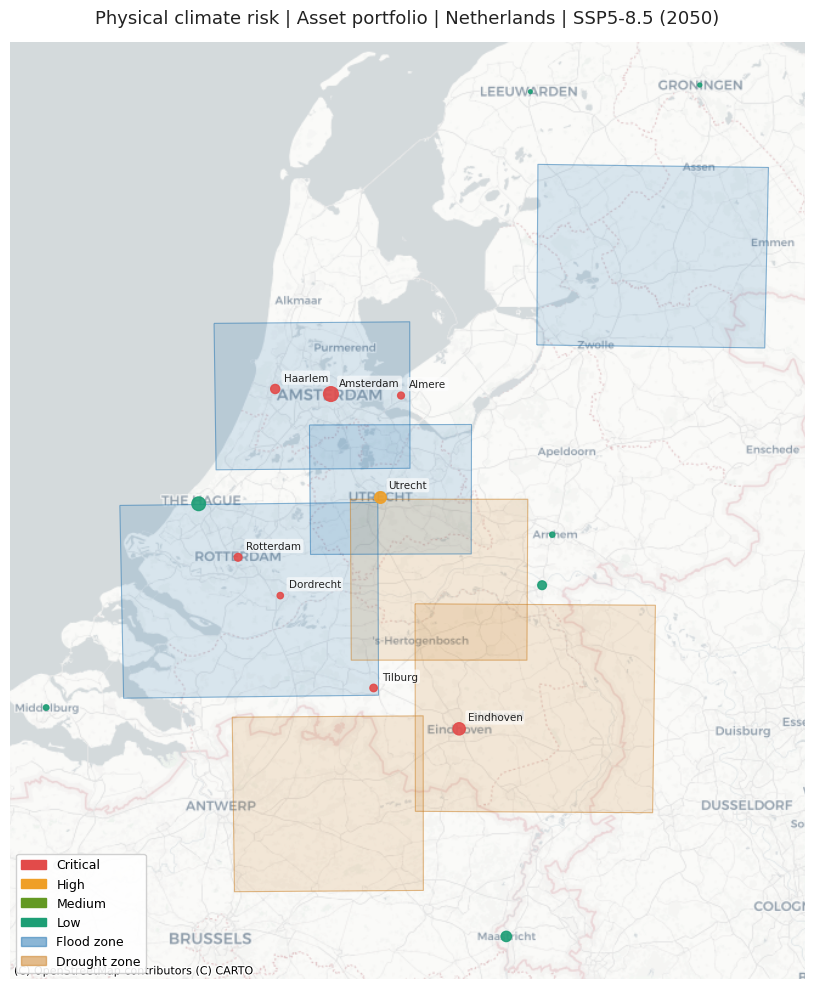

Saved: output/risk_map.png


In [10]:
# Convert back to WGS84 for contextily (which uses Web Mercator tiles)
gdf_wm      = gdf_rd.to_crs("EPSG:3857")
flood_wm    = flood_zones.to_crs("EPSG:3857")
drought_wm  = drought_zones.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("white")

# Draw hazard zones first (background layer)
flood_wm.plot(ax=ax, color="#1a6faf", alpha=0.15, zorder=1)
flood_wm.boundary.plot(ax=ax, color="#1a6faf", linewidth=0.8, alpha=0.5, zorder=2)

drought_wm.plot(ax=ax, color="#c97a1a", alpha=0.15, zorder=1)
drought_wm.boundary.plot(ax=ax, color="#c97a1a", linewidth=0.8, alpha=0.5, zorder=2)

# Plot assets, sized by asset value, coloured by risk tier
for tier, color in RISK_COLORS.items():
    subset = gdf_wm[gdf_wm["risk_tier"] == tier]
    if len(subset) == 0:
        continue
    subset.plot(
        ax=ax,
        color=color,
        markersize=subset["value_eur_m"] * 2.5,
        alpha=0.9,
        zorder=4,
        label=tier
    )

# Add asset name labels for the highest-risk ones
for _, row in gdf_wm[gdf_wm["risk_tier"].isin(["Critical","High"])].iterrows():
    ax.annotate(
        row["asset_name"].split()[0],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6), textcoords="offset points",
        fontsize=7.5, color="#222",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, lw=0)
    )

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

# Legend for risk tiers
handles = [mpatches.Patch(color=c, label=t) for t, c in RISK_COLORS.items()]
flood_patch   = mpatches.Patch(color="#1a6faf", alpha=0.5, label="Flood zone")
drought_patch = mpatches.Patch(color="#c97a1a", alpha=0.5, label="Drought zone")
ax.legend(handles=handles + [flood_patch, drought_patch],
          loc="lower left", fontsize=9, framealpha=0.9)

ax.set_title("Physical climate risk | Asset portfolio | Netherlands | SSP5-8.5 (2050)",
             fontsize=13, pad=14, color="#222")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("output/risk_map.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: output/risk_map.png")

## 10. Risk matrix chart

The risk matrix plots flood vs drought exposure for both scenarios side by side.
Dot size represents asset book value so you can see capital concentration at a glance.

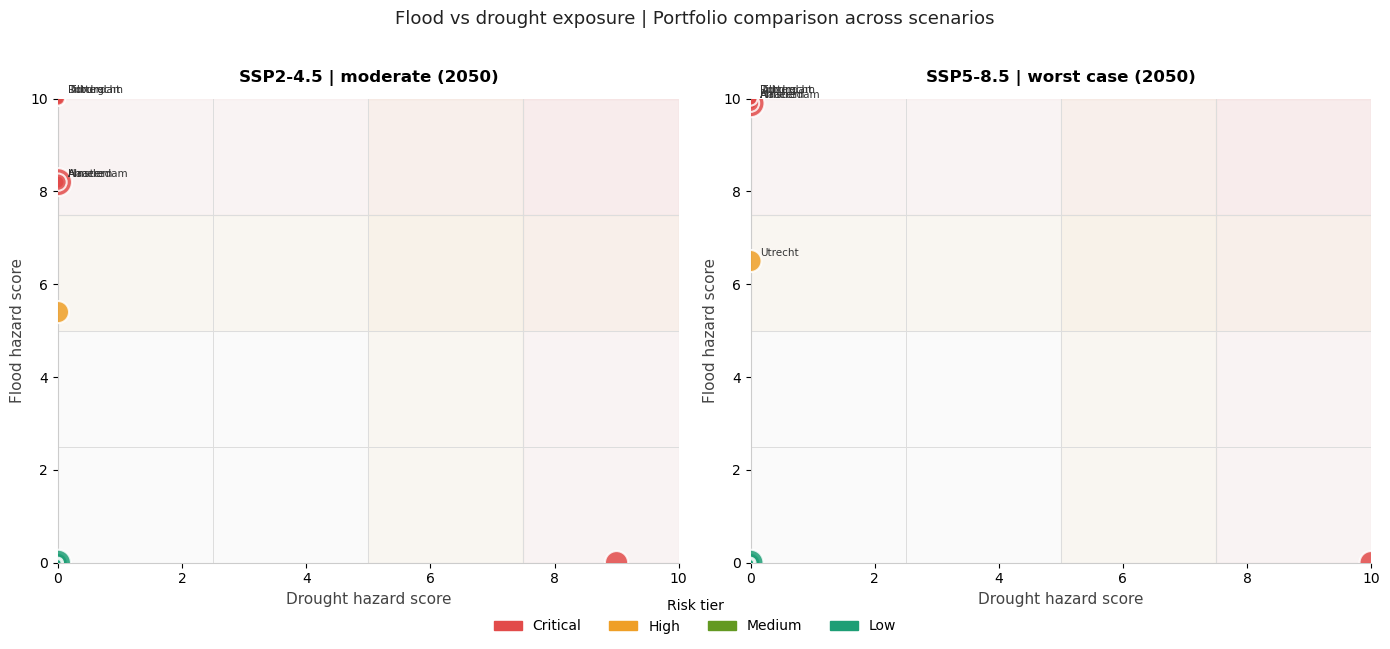

Saved: output/risk_matrix.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

scenarios = [
    ("ssp245", "flood_ssp245", "drought_ssp245", "SSP2-4.5 | moderate (2050)"),
    ("ssp585", "flood_ssp585", "drought_ssp585", "SSP5-8.5 | worst case (2050)"),
]

for ax, (sc, fcol, dcol, title) in zip(axes, scenarios):
    tier_col = "risk_tier" if sc == "ssp585" else gdf_rd[["flood_ssp245","drought_ssp245"]].max(axis=1).apply(classify)
    if sc == "ssp245":
        colors = gdf_rd[["flood_ssp245","drought_ssp245"]].max(axis=1).apply(classify).map(RISK_COLORS)
    else:
        colors = gdf_rd["risk_tier"].map(RISK_COLORS)

    ax.scatter(
        gdf_rd[dcol], gdf_rd[fcol],
        s=gdf_rd["value_eur_m"] * 9,
        c=colors, alpha=0.85, edgecolors="white", linewidths=1.5, zorder=3
    )

    # Threshold shading
    ax.axhspan(7.5, 10, alpha=0.04, color="#E24B4A", zorder=0)
    ax.axhspan(5.0, 7.5, alpha=0.04, color="#EF9F27", zorder=0)
    ax.axvspan(7.5, 10, alpha=0.04, color="#E24B4A", zorder=0)
    ax.axvspan(5.0, 7.5, alpha=0.04, color="#EF9F27", zorder=0)
    for t in [2.5, 5.0, 7.5]:
        ax.axhline(t, color="#ddd", linewidth=0.7, zorder=1)
        ax.axvline(t, color="#ddd", linewidth=0.7, zorder=1)

    # Label high-risk assets
    high_risk = gdf_rd[gdf_rd[fcol] >= 5.5]
    for _, row in high_risk.iterrows():
        ax.annotate(row["asset_name"].split()[0],
                    (row[dcol], row[fcol]),
                    textcoords="offset points", xytext=(7, 4),
                    fontsize=7.5, color="#333")

    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_xlabel("Drought hazard score", fontsize=11, color="#444")
    ax.set_ylabel("Flood hazard score", fontsize=11, color="#444")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.set_facecolor("#fafafa")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#ccc")

patches = [mpatches.Patch(color=v, label=k) for k, v in RISK_COLORS.items()]
fig.legend(handles=patches, title="Risk tier", loc="lower center",
           ncol=4, bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10)
plt.suptitle("Flood vs drought exposure | Portfolio comparison across scenarios",
             fontsize=13, y=1.02, color="#222")
plt.tight_layout()
plt.savefig("output/risk_matrix.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: output/risk_matrix.png")

## 11. Interactive map

The Folium map is the version you share with a client. It is fully interactive:
zoom, pan, and click any asset to see the full hazard breakdown.
Circle size scales with asset value so capital concentration is immediately visible.

In [12]:
# Convert hazard zones back to WGS84 for Folium
flood_wgs  = flood_zones.to_crs("EPSG:4326")
drought_wgs = drought_zones.to_crs("EPSG:4326")

m = folium.Map(location=[52.3, 5.2], zoom_start=8, tiles="CartoDB positron")

# Add hazard zones as semi-transparent overlays
for _, zone in flood_wgs.iterrows():
    folium.GeoJson(
        zone.geometry.__geo_interface__,
        style_function=lambda _: {
            "fillColor": "#1a6faf", "color": "#1a6faf",
            "weight": 1, "fillOpacity": 0.12
        },
        tooltip=zone["label"]
    ).add_to(m)

for _, zone in drought_wgs.iterrows():
    folium.GeoJson(
        zone.geometry.__geo_interface__,
        style_function=lambda _: {
            "fillColor": "#c97a1a", "color": "#c97a1a",
            "weight": 1, "fillOpacity": 0.12
        },
        tooltip=zone["label"]
    ).add_to(m)

FOLIUM_COLORS = {"Critical":"red","High":"orange","Medium":"green","Low":"darkgreen"}

# Add asset markers
for _, row in gdf.iterrows():
    rd_row    = gdf_rd[gdf_rd["asset_id"] == row["asset_id"]].iloc[0]
    tier      = rd_row["risk_tier"]
    fc        = rd_row["flood_ssp585"]
    dc        = rd_row["drought_ssp585"]
    pct       = rd_row["pct_buffer_flooded"]
    rc        = RISK_COLORS[tier]

    popup_html = (
        f"<div style='font-family:sans-serif;font-size:13px;min-width:220px;'>"
        f"<b style='font-size:14px;'>{row['asset_name']}</b><br>"
        f"<span style='color:#666;'>{row['sector'].title()}</span><br><br>"
        f"<b>Book value:</b> €{row['value_eur_m']}M<br>"
        f"<b>1km buffer flooded:</b> {pct}%<br><br>"
        f"<table style='border-collapse:collapse;width:100%;'>"
        f"<tr style='background:#f5f5f5;'>"
        f"<th style='padding:4px 8px;text-align:left;'>Hazard</th>"
        f"<th style='padding:4px 8px;'>SSP2-4.5</th>"
        f"<th style='padding:4px 8px;'>SSP5-8.5</th></tr>"
        f"<tr><td style='padding:4px 8px;'>Flood</td>"
        f"<td style='padding:4px 8px;text-align:center;'>{rd_row['flood_ssp245']}</td>"
        f"<td style='padding:4px 8px;text-align:center;'><b>{fc}</b></td></tr>"
        f"<tr style='background:#f5f5f5;'><td style='padding:4px 8px;'>Drought</td>"
        f"<td style='padding:4px 8px;text-align:center;'>{rd_row['drought_ssp245']}</td>"
        f"<td style='padding:4px 8px;text-align:center;'><b>{dc}</b></td></tr>"
        f"</table><br>"
        f"<span style='background:{rc};color:white;padding:3px 10px;"
        f"border-radius:4px;font-size:12px;font-weight:bold;'>{tier.upper()} RISK</span>"
        f"</div>"
    )

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=9 + row["value_eur_m"] / 9,
        color=FOLIUM_COLORS[tier], fill=True,
        fill_color=FOLIUM_COLORS[tier], fill_opacity=0.78,
        popup=folium.Popup(popup_html, max_width=290),
        tooltip=f"{row['asset_name']} | {tier}"
    ).add_to(m)

# Legend
legend = (
    "<div style='position:fixed;bottom:28px;left:28px;z-index:1000;"
    "background:white;padding:12px 16px;border-radius:8px;"
    "border:1px solid #ddd;font-family:sans-serif;font-size:12px;'>"
    "<b style='font-size:13px;'>Risk tier (SSP5-8.5)</b><br>"
    "<span style='color:#E24B4A;'>&#9679;</span> Critical (&ge;7.5)<br>"
    "<span style='color:#EF9F27;'>&#9679;</span> High (5.0–7.4)<br>"
    "<span style='color:#639922;'>&#9679;</span> Medium (2.5–4.9)<br>"
    "<span style='color:#1D9E75;'>&#9679;</span> Low (&lt;2.5)<br>"
    "<span style='color:#1a6faf;'>&#9632;</span> Flood zone<br>"
    "<span style='color:#c97a1a;'>&#9632;</span> Drought zone<br>"
    "<span style='color:#888;font-size:11px;'>Circle size = asset value</span></div>"
)
m.get_root().html.add_child(folium.Element(legend))
m.save("output/risk_map_interactive.html")
print("Saved: output/risk_map_interactive.html")
m

Saved: output/risk_map_interactive.html


## 12. Summary tables and export

Finally we export two things: a full asset-level CSV with all computed scores,
and an aggregated summary table that can go straight into a report.

We also do one last GeoPandas operation: dissolve the risk tiers into grouped polygons
so you can see the spatial footprint of each tier across the portfolio.

In [13]:
# Full asset export
export_cols = [
    "asset_id","asset_name","sector","value_eur_m",
    "flood_score","drought_score",
    "flood_ssp245","flood_ssp585",
    "drought_ssp245","drought_ssp585",
    "composite_ssp245","composite_ssp585",
    "pct_buffer_flooded","risk_tier",
    "flood_zone","drought_zone"
]
gdf_rd[export_cols].to_csv("output/asset_risk_scores.csv", index=False)

# Summary by risk tier
summary = gdf_rd.groupby("risk_tier").agg(
    assets        = ("asset_id",         "count"),
    total_value   = ("value_eur_m",       "sum"),
    avg_flood     = ("flood_ssp585",      "mean"),
    avg_drought   = ("drought_ssp585",    "mean"),
    avg_pct_flood = ("pct_buffer_flooded","mean")
).round(2).reset_index()
summary.columns = [
    "Risk tier","Assets","Total value (EUR M)",
    "Avg flood score","Avg drought score","Avg % buffer flooded"
]
order = ["Critical","High","Medium","Low"]
summary["Risk tier"] = pd.Categorical(summary["Risk tier"], categories=order, ordered=True)
summary = summary.sort_values("Risk tier")
summary.to_csv("output/risk_summary.csv", index=False)

print("Saved: output/asset_risk_scores.csv")
print("Saved: output/risk_summary.csv")
print()
summary

Saved: output/asset_risk_scores.csv
Saved: output/risk_summary.csv



,Risk tier,Assets,Total value (EUR M),Avg flood score,Avg drought score,Avg % buffer flooded
0,Critical,7,135.1,8.53,1.43,85.54
1,High,1,28.0,6.50,0.00,99.80
2,Low,7,94.0,0.00,0.00,6.39


In [14]:
# Convex hull per risk tier: spatial footprint of each risk group
hulls = gdf_rd.dissolve(by="risk_tier", aggfunc="count")
hulls["geometry"] = hulls.geometry.convex_hull
hulls_wgs = hulls.to_crs("EPSG:4326")
hulls_wgs.to_file("output/risk_tier_hulls.geojson", driver="GeoJSON")

print("Saved: output/risk_tier_hulls.geojson")
print()
print("Total portfolio exposure summary:")
total_val = gdf_rd["value_eur_m"].sum()
high_val  = gdf_rd[gdf_rd["risk_tier"].isin(["Critical","High"])]["value_eur_m"].sum()
print(f"  Total portfolio value:              EUR {total_val:.1f}M")
print(f"  Value in Critical or High tier:     EUR {high_val:.1f}M ({high_val/total_val*100:.0f}%)")
print(f"  Average composite score (SSP5-8.5): {gdf_rd['composite_ssp585'].mean():.1f} / 10")

Saved: output/risk_tier_hulls.geojson

Total portfolio exposure summary:
  Total portfolio value:              EUR 257.1M
  Value in Critical or High tier:     EUR 163.1M (63%)
  Average composite score (SSP5-8.5): 5.1 / 10


## Done

All output files are in the `output/` folder:

| File | What it is |
|------|------------|
| `asset_risk_scores.csv` | Full asset-level hazard scores across both scenarios |
| `risk_summary.csv` | Aggregated by risk tier, ready to paste into a report |
| `risk_map.png` | Static map with basemap, for slides and PDF reports |
| `risk_matrix.png` | Flood vs drought scatter, SSP2-4.5 vs SSP5-8.5 |
| `risk_map_interactive.html` | Clickable map, open in any browser |
| `risk_tier_hulls.geojson` | Spatial footprint of each risk tier, load in QGIS or ArcGIS |

**To connect real data**, replace the dummy `data` dictionary in Cell 2 with a CSV from
your client, and replace the synthetic hazard zones in Cell 4 with a `gpd.read_file()`
call pointing at a real shapefile or a `rasterstats.zonal_stats()` call on a GeoTIFF.
The rest of the notebook runs unchanged.